# CS108/212 STAT108/212 W26 Course Project

### Team Details

- Teammate 1: Haz Sameen Shahgir
- Teammate 2: Jasmine Ruvalcaba
- Teammate 3: Will Kirkpatrick
- Teammate 4: Name

---

# Installs

In [4]:
# [INSERT CODE HERE to install necessary packages]
# ! pip install fairlearn lightgbm

# Imports

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate,
)
import lightgbm as lgb
from xgboost import XGBClassifier

## Add additional imports needed for your project here.

# Loading dataset
_(same as previous milestone, copy-paste)_

In [6]:
import pandas as pd

df = pd.read_csv('hmda_riverside_2024.csv', low_memory=False)

# Convert numeric columns that might have mixed types
numeric_columns = ['loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread',
                   'total_loan_costs', 'total_points_and_fees', 'origination_charges',
                   'discount_points', 'lender_credits', 'loan_term', 'property_value',
                   'income', 'debt_to_income_ratio']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

# Filter to binary target
df = df[df["action_taken"].isin([1, 3])].copy()
df["action_taken"] = df["action_taken"].map({1: 1, 3: 0})


In [7]:
# Load your selected dataset

X = df.drop(columns=["action_taken"])  # features
y = df["action_taken"]  # target
sensitive_feature_colname = "derived_race"  # sensitive feature name

# Make sensitive features-based group labels
group_labels = df[sensitive_feature_colname]

# Print some stats
print(f"No. of samples: {X.shape[0]}")
print(f"No. of features: {X.shape[1]}")
print(f"Group Counts: {dict(collections.Counter(group_labels))}")

No. of samples: 65174
No. of features: 98
Group Counts: {'White': 34485, 'Asian': 5937, 'Black or African American': 3827, 'Race Not Available': 17614, 'Joint': 1985, 'American Indian or Alaska Native': 778, '2 or more minority races': 208, 'Native Hawaiian or Other Pacific Islander': 299, 'Free Form Text Only': 41}


In [8]:
# Some subset of following dataset preparation steps may be necessary depending on your dataset,
# 1. Drop unnecessary features
# 2. Handle missing data
# 3. Encode categorical features
# 4. Normalize numerical features
# 5. Encode target (if your task is classification)

# Drop columns
cols_to_drop = [
    # Identifiers
    "activity_year", "lei", "census_tract",
    # Redundant derived columns
    "derived_loan_product_type", "derived_dwelling_category",
    # Post-decision leakage
    "purchaser_type", "rate_spread", "total_loan_costs", "origination_charges",
    "discount_points", "lender_credits", "interest_rate",
    "denial_reason-1", "denial_reason-2", "denial_reason-3", "denial_reason-4",
    # Near-complete missingness
    "applicant_ethnicity-2", "applicant_ethnicity-3", "applicant_ethnicity-4", "applicant_ethnicity-5",
    "co-applicant_ethnicity-2", "co-applicant_ethnicity-3", "co-applicant_ethnicity-4", "co-applicant_ethnicity-5",
    "applicant_race-2", "applicant_race-3", "applicant_race-4", "applicant_race-5",
    "co-applicant_race-2", "co-applicant_race-3", "co-applicant_race-4", "co-applicant_race-5",
    "aus-2", "aus-3", "aus-4", "aus-5",
    "total_points_and_fees", "prepayment_penalty_term", "multifamily_affordable_units", "intro_rate_period",
]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

# Median imputation
median_cols = ["loan_to_value_ratio", "property_value", "income", "loan_term"]
for col in median_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X[col] = X[col].fillna(X[col].median())

# Mode imputation
mode_cols = [
    "conforming_loan_limit", "applicant_race-1", "applicant_ethnicity-1",
    "co-applicant_race-1", "co-applicant_ethnicity-1", "state_code",
]
for col in mode_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

# Missing as own category
for col in ["debt_to_income_ratio", "applicant_age_above_62", "co-applicant_age_above_62"]:
    if col in X.columns:
        X[col] = X[col].fillna("Missing")

# Encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Normalize numerical features
numerical_cols = [c for c in ['loan_amount', 'loan_to_value_ratio', 'property_value', 'income', 'loan_term'] if c in X.columns]
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Reset indices for alignment
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
group_labels = group_labels.reset_index(drop=True)

# Note: X and y have been modified before the following lines of code!
print(f"No. of samples AFTER cleaning: {X.shape[0]}")
assert X.shape[0] == y.shape[0] == group_labels.shape[0] ## Ensure that the target and group_labels have been updated if some samples were removed during cleaning.
print(f"No. of features AFTER encoding: {X.shape[1]}")

No. of samples AFTER cleaning: 65174
No. of features AFTER encoding: 104


In [9]:
X_train, X_test, \
  y_train, y_test, \
    group_labels_train, group_labels_test = train_test_split(X, y, group_labels,
                                                             test_size=0.2, random_state=42)

# Binarize group labels: White vs Non-White
group_labels_train = group_labels_train.map(lambda x: 'White' if x == 'White' else 'Non-White')
group_labels_test = group_labels_test.map(lambda x: 'White' if x == 'White' else 'Non-White')

print(f"No. of training samples: {X_train.shape[0]}")
print(f"No. of testing samples: {X_test.shape[0]}")
print(f"Group counts (train): {dict(collections.Counter(group_labels_train))}")
print(f"Group counts (test): {dict(collections.Counter(group_labels_test))}")

# Delete X, y and group_label variables to make sure they are not used later on.
del X
del y
del group_labels

No. of training samples: 52139
No. of testing samples: 13035
Group counts (train): {'White': 27618, 'Non-White': 24521}
Group counts (test): {'Non-White': 6168, 'White': 6867}


# Setting up evaluation metrics
Note: The same evaluation function will be used by all teammates.

_(same as previous milestone, copy-paste)_

In [10]:
def evaluate_model(y_test, y_pred, g_labels):
  """
  Evaluate the performance of your trained model on the testing set.

  Parameters
  ----------
  y_test : array-like
    The true targets of the testing set.
  y_pred : array-like
    The predicted targets of the testing set.
  g_labels : array-like
    The group labels of the testing set.

  Returns
  -------
  results : dict
    A dictionary containing the evaluation results.

    Example:
      For classification task, the task-specific performance metrics like {'accuracy': <value>, 'f1_score': <value>, ...}
      and fairness metrics like {'demographic_parity': <value>, 'equalized_odds': <value>, ...}.

  """

  results = {}

  y_test = np.asarray(y_test)
  y_pred = np.asarray(y_pred)
  g_labels = np.asarray(g_labels)

  mf = MetricFrame(
      metrics={
          'accuracy': accuracy_score,
          'f1': f1_score,
          'selection_rate': selection_rate,
      },
      y_true=y_test,
      y_pred=y_pred,
      sensitive_features=g_labels,
  )

  results['accuracy'] = mf.overall['accuracy']
  results['f1_score'] = mf.overall['f1']

  results['demographic_parity'] = demographic_parity_difference(
      y_test,
      y_pred,
      sensitive_features=g_labels,
  )
  results['equalized_odds'] = equalized_odds_difference(
      y_test,
      y_pred,
      sensitive_features=g_labels,
  )

  selection_by_group = mf.by_group['selection_rate']
  results['disparate_impact_ratio'] = selection_by_group.min() / selection_by_group.max()

  mf_tpr = MetricFrame(
      metrics=true_positive_rate,
      y_true=y_test,
      y_pred=y_pred,
      sensitive_features=g_labels,
  )
  tpr_by_group = mf_tpr.by_group
  results['equal_opportunity'] = tpr_by_group.max() - tpr_by_group.min()

  return results

# Training baseline models (INDIVIDUAL CONTRIBUTION)

In [11]:
## A place to save all teammates's baseline results
all_baseline_results = [] ## DO NOT EDIT

## Teammate 1

In [12]:
# Select a model and train it on the training set
# [INSERT YOUR CODE HERE]
model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the testing set and store them in y_pred
y_pred = model.predict(X_test)

# Evaluate testing set predictions using evaluate_model()
results = evaluate_model(y_test, y_pred, group_labels_test)

# Save your results to all_baseline_results
results['teammate'] = 'Teammate 1 - Haz'
results['experiment_type'] = 'baseline'
results['predictor_model'] = 'LGBMClassifier' #[INSERT MODEL NAME HERE]
results['mitigation_strategy'] = 'NONE' ## DO NOT EDIT: This is pre-mitigation baseline
all_baseline_results.append(results)

pprint(results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 37724, number of negative: 14415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 52139, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.723527 -> initscore=0.962027
[LightGBM] [Info] Start training from score 0.962027
{'accuracy': 0.9790563866513233,
 'demographic_parity': 0.03760810598707287,
 'disparate_impact_ratio': 0.9493518604014063,
 'equal_opportunity': 6.732264781439401e-05,
 'equalized_odds': 0.006220446284341673,
 'experiment_type': 'baseline',
 'f1_score': 0.9855010887460832,
 'mitigation_strategy': 'NONE',
 'predictor_model': 'LGBMClassifier',
 'teammate': 'Teamm

## Teammate 2

In [13]:
from sklearn.linear_model import LogisticRegression
from pprint import pprint
import numpy as np

model = LogisticRegression(
    solver="saga",
    max_iter=2000,
    tol=1e-2,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("y_pred counts:", np.unique(y_pred, return_counts=True))

results = evaluate_model(y_test, y_pred, group_labels_test)

results["teammate"] = "Teammate 2 - Jasmine"
results["experiment_type"] = "baseline"
results["predictor_model"] = "LogisticRegression (balanced)"
results["mitigation_strategy"] = "NONE"

all_baseline_results.append(results)

pprint(results)

y_pred counts: (array([0, 1]), array([6902, 6133]))
{'accuracy': 0.5040276179516686,
 'demographic_parity': 0.0027880337870342387,
 'disparate_impact_ratio': 0.9940909172791469,
 'equal_opportunity': 0.005305683238892633,
 'equalized_odds': 0.0177694057656953,
 'experiment_type': 'baseline',
 'f1_score': 0.5833064776023204,
 'mitigation_strategy': 'NONE',
 'predictor_model': 'LogisticRegression (balanced)',
 'teammate': 'Teammate 2 - Jasmine'}


## Teammate 3

In [14]:
import re
from xgboost import XGBClassifier

X_train_xgb = X_train.rename(columns=lambda c: re.sub(r'[\[\]<]', '_', c))
X_test_xgb = X_test.rename(columns=lambda c: re.sub(r'[\[\]<]', '_', c))

model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
model.fit(X_train_xgb, y_train)

y_pred = model.predict(X_test_xgb)

results = evaluate_model(y_test, y_pred, group_labels_test)

results['teammate'] = 'Teammate 3'
results['experiment_type'] = 'baseline'
results['predictor_model'] = "XGBClassifier"
results['mitigation_strategy'] = 'NONE'
all_baseline_results.append(results)

pprint(results)

/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:10:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'accuracy': 0.9779823551975451,
 'demographic_parity': 0.03433836557743308,
 'disparate_impact_ratio': 0.953591506313672,
 'equal_opportunity': 0.0026961988681746263,
 'equalized_odds': 0.0026961988681746263,
 'experiment_type': 'baseline',
 'f1_score': 0.9847462131278235,
 'mitigation_strategy': 'NONE',
 'predictor_model': 'XGBClassifier',
 'teammate': 'Teammate 3'}


## Teammate 4

In [15]:
# # Select a model and train it on the training set
# # [INSERT YOUR CODE HERE]

# # Make predictions on the testing set and store them in y_pred
# y_pred = ... # [INSERT CODE HERE]

# # Evaluate testing set predictions using evaluate_model()
# results = evaluate_model(y_test, y_pred, group_labels_test)

# # Save your results to all_baseline_results
# results['teammate'] = 'Teammate 4'
# results['experiment_type'] = 'baseline'
# results['predictor_model'] = ... #[INSERT MODEL NAME HERE]
# results['mitigation_strategy'] = 'NONE' ## DO NOT EDIT: This is pre-mitigation baseline
# all_baseline_results.append(results)

# pprint(results)

# Mitigating Bias (INDIVIDUAL CONTRIBUTION)



In [16]:
## A place to save all teammates' post-mitigation results
all_mitigated_results = [] ## DO NOT EDIT

## Teammate 1

In [17]:
# Inprocessing: Demographic Parity Loss Function Regularization
def sigmoid(x):
    return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

# Build per-group masks (White vs Non-White)
groups_train = group_labels_train.values
unique_groups = np.unique(groups_train)
group_masks = {g: (groups_train == g) for g in unique_groups}
group_sizes = {g: m.sum() for g, m in group_masks.items()}
print(f"Groups: {dict(group_sizes)}")

def make_fair_objective(group_masks, group_sizes, lambda_fair=1.0):
    def objective(y_true, y_pred_raw):
        p = sigmoid(y_pred_raw)
        grad = p - y_true
        hess = p * (1 - p)

        group_means = {g: p[mask].mean() for g, mask in group_masks.items()}
        g_max = max(group_means, key=group_means.get)
        g_min = min(group_means, key=group_means.get)
        gap = group_means[g_max] - group_means[g_min]

        dp = p * (1 - p)
        grad[group_masks[g_max]] += lambda_fair * 2 * gap / group_sizes[g_max] * dp[group_masks[g_max]]
        grad[group_masks[g_min]] -= lambda_fair * 2 * gap / group_sizes[g_min] * dp[group_masks[g_min]]
        return grad, hess
    return objective

model_fair = lgb.LGBMClassifier(random_state=42, objective=make_fair_objective(group_masks, group_sizes, lambda_fair=1.0))
model_fair.fit(X_train, y_train)

y_pred_raw = model_fair.predict(X_test, raw_score=True)
y_pred_mitigated = (sigmoid(y_pred_raw) >= 0.5).astype(int)

results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)
results_mitigated['teammate'] = 'Teammate 1'
results_mitigated['experiment_type'] = 'post-mitigation'
results_mitigated['predictor_model'] = 'LGBMClassifier'
results_mitigated['mitigation_strategy'] = 'inprocessing'
all_mitigated_results.append(results_mitigated)

pprint(results_mitigated)

Groups: {'Non-White': 24521, 'White': 27618}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 52139, number of used features: 97
[LightGBM] [Info] Using self-defined objective function
{'accuracy': 0.9789029535864979,
 'demographic_parity': 0.03636059845230588,
 'disparate_impact_ratio': 0.9510030946679779,
 'equal_opportunity': 6.732264781439401e-05,
 'equalized_odds': 0.0018549210122046425,
 'experiment_type': 'post-mitigation',
 'f1_score': 0.9853964207954968,
 'mitigation_strategy': 'inprocessing',
 'predictor_model': 'LGBMClassifier',
 'teammate': 'Teammate 1'}


In [18]:
# Inprocessing: Equalized Odds Regularization
# Penalizes TPR and FPR gaps separately (White vs Non-White)

y_train_arr = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
group_pos = {g: group_masks[g] & (y_train_arr == 1) for g in unique_groups}
group_neg = {g: group_masks[g] & (y_train_arr == 0) for g in unique_groups}

def make_eo_objective(group_pos, group_neg, lambda_fair=1.0):
    pos_sizes = {g: m.sum() for g, m in group_pos.items()}
    neg_sizes = {g: m.sum() for g, m in group_neg.items()}

    def objective(y_true, y_pred_raw):
        p = sigmoid(y_pred_raw)
        grad = p - y_true
        hess = p * (1 - p)
        dp = p * (1 - p)

        for masks, sizes in [(group_pos, pos_sizes), (group_neg, neg_sizes)]:
            means = {g: p[masks[g]].mean() for g in sizes}
            g_hi, g_lo = max(means, key=means.get), min(means, key=means.get)
            gap = means[g_hi] - means[g_lo]
            grad[masks[g_hi]] += lambda_fair * 2 * gap / sizes[g_hi] * dp[masks[g_hi]]
            grad[masks[g_lo]] -= lambda_fair * 2 * gap / sizes[g_lo] * dp[masks[g_lo]]

        return grad, hess
    return objective

model_eo = lgb.LGBMClassifier(random_state=42, objective=make_eo_objective(group_pos, group_neg, lambda_fair=1.0))
model_eo.fit(X_train, y_train)

y_pred_eo = (sigmoid(model_eo.predict(X_test, raw_score=True)) >= 0.5).astype(int)
results_eo = evaluate_model(y_test, y_pred_eo, group_labels_test)

results_eo['teammate'] = 'Teammate 1'
results_eo['experiment_type'] = 'post-mitigation (EO)'
results_eo['predictor_model'] = 'LGBMClassifier'
results_eo['mitigation_strategy'] = 'inprocessing'
all_mitigated_results.append(results_eo)

pprint(results_eo)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 52139, number of used features: 97
[LightGBM] [Info] Using self-defined objective function
{'accuracy': 0.9789029535864979,
 'demographic_parity': 0.03636059845230588,
 'disparate_impact_ratio': 0.9510030946679779,
 'equal_opportunity': 6.732264781439401e-05,
 'equalized_odds': 0.0018549210122046425,
 'experiment_type': 'post-mitigation (EO)',
 'f1_score': 0.9853964207954968,
 'mitigation_strategy': 'inprocessing',
 'predictor_model': 'LGBMClassifier',
 'teammate': 'Teammate 1'}


### Teammate 1's Conclusions
[Briefly describe findings and conclusions here. Compare post-mitigation results with baseline results for your model. What is the % improvement in performance post-mitigation?  ]

### Teammate 1's Conclusions

**Strategy:** Inprocessing — two custom LightGBM loss functions that add fairness regularization to binary cross-entropy: (1) **Demographic Parity (DP) regularization**, which penalizes the gap in mean predicted probability between White and Non-White groups, and (2) **Equalized Odds (EO) regularization**, which separately penalizes TPR and FPR gaps. Both use `lambda_fair=1.0`. Groups were binarized to White vs Non-White for stable metrics.

To understand how geography affects fairness, the pipeline was run across four counties.

**Riverside, CA** (13,035 test samples)

| Metric | Goal | Baseline | DP Reg | EO Reg |
|---|---|---|---|---|
| Accuracy | higher | 0.9791 | 0.9787 | 0.9787 |
| F1 Score | higher | 0.9855 | 0.9852 | 0.9852 |
| Demographic Parity | lower | 0.037 | 0.036 | 0.036 |
| Equalized Odds Diff | lower | 0.004 | 0.0004 (−90%) | 0.0004 (−90%) |
| Disparate Impact | higher | 0.950 | 0.952 | 0.952 |

**Orange County, CA** (10,295 test samples)

| Metric | Goal | Baseline | DP Reg | EO Reg |
|---|---|---|---|---|
| Accuracy | higher | 0.9743 | 0.9731 | 0.9731 |
| F1 Score | higher | 0.9830 | 0.9823 | 0.9823 |
| Demographic Parity | lower | 0.017 | 0.017 | 0.017 |
| Equalized Odds Diff | lower | 0.003 | 0.006 (+91%) | 0.006 (+91%) |
| Disparate Impact | higher | 0.978 | 0.978 | 0.978 |

**Imperial County, CA** (481 test samples)

| Metric | Goal | Baseline | DP Reg | EO Reg |
|---|---|---|---|---|
| Accuracy | higher | 0.9667 | 0.9584 | 0.9605 |
| F1 Score | higher | 0.9774 | 0.9718 | 0.9733 |
| Demographic Parity | lower | 0.052 | 0.049 | 0.052 |
| Equalized Odds Diff | lower | 0.013 | 0.013 (0%) | 0.013 (0%) |
| Disparate Impact | higher | 0.931 | 0.935 | 0.931 |

**Shelby County, TN** (3,878 test samples)

| Metric | Goal | Baseline | DP Reg | EO Reg |
|---|---|---|---|---|
| Accuracy | higher | 0.9783 | 0.9791 | 0.9776 |
| F1 Score | higher | 0.9852 | 0.9857 | 0.9846 |
| Demographic Parity | lower | 0.141 | 0.142 | 0.143 |
| Equalized Odds Diff | lower | 0.018 | 0.012 (−35%) | 0.012 (−33%) |
| Disparate Impact | higher | 0.828 | 0.827 | 0.826 |

**Key findings:**

1. Demographic parity: California counties show near-perfect DP (0.017–0.052), while Shelby County, TN has a large gap (0.141). No inprocessing method meaningfully reduced DP.  White and Non-White applicants in Shelby County don't have the same features on average. White applicants tend to have higher incomes, lower DTI ratios, higher property values, etc. — so they get approved more often. The model is just reflecting that reality.

2. **Regularization Effects Equalized odds ** In Riverside and Shelby, both regularizations reduced equalized odds by 33–90% with negligible accuracy loss. But it increases it for Orange Country.

**Conclusion:** Inprocessing fairness regularization is effective at reducing equalized odds in counties with measurable disparities (Shelby, Riverside), but cannot address demographic parity gaps rooted in actual differences between groups. The DP gap in Shelby County (0.14) persists despite in-processing.

## Teammate 2

In [19]:
# Implement your bias mitigation strategy
## If you chose preprocessing, you will train a new version of your predictor model with new/modified inputs.
## If you chose inprocessing, you will train a new version of your predictor with modified learning objective (loss function).
## If you chose postprocessing, you will implement strategies to modify the predictions (y_pred) of the trained baseline predictor model from the previous milestone without training any new version of the predictor model.

# make sure list exists

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression


s_train = pd.Series(group_labels_train).reset_index(drop=True)
y_train_s = pd.Series(y_train).reset_index(drop=True)

joint = pd.crosstab(s_train, y_train_s).astype(float)
P_sy = joint / joint.values.sum()

P_s = P_sy.sum(axis=1)
P_y = P_sy.sum(axis=0)

W = pd.DataFrame(index=P_sy.index, columns=P_sy.columns, dtype=float)
for s in P_sy.index:
    for y in P_sy.columns:
        if P_sy.loc[s, y] == 0:
            W.loc[s, y] = 0
        else:
            W.loc[s, y] = (P_s.loc[s] * P_y.loc[y]) / P_sy.loc[s, y]

sample_weight = np.array([W.loc[s, y] for s, y in zip(s_train, y_train_s)])
sample_weight = sample_weight / np.mean(sample_weight)

model_mitigated = LogisticRegression(
    solver="saga",
    max_iter=2000,
    tol=1e-2,
    class_weight="balanced"
)

model_mitigated.fit(X_train, y_train, sample_weight=sample_weight)

# predict
y_pred_mitigated = model_mitigated.predict(X_test)

# evaluate
results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)

# Save your results to all_mitigated_results
results_mitigated["teammate"] = "Teammate 2 - Jasmine"
results_mitigated["experiment_type"] = "post-mitigation"
results_mitigated["predictor_model"] = "LogisticRegression (balanced, weighted)"
results_mitigated["mitigation_strategy"] = "preprocessing"

all_mitigated_results.append(results_mitigated)

print(results_mitigated)
# Table
results_df = pd.DataFrame([results_mitigated])
results_clean = results_df.drop_duplicates(
    subset=["experiment_type","predictor_model","mitigation_strategy"]
)


results_clean.reset_index(drop=True)

{'accuracy': 0.5054852320675105, 'f1_score': 0.5864237135891185, 'demographic_parity': 0.005337728684924659, 'equalized_odds': 0.013586551862038332, 'disparate_impact_ratio': 0.9888509615548204, 'equal_opportunity': 0.013586551862038332, 'teammate': 'Teammate 2 - Jasmine', 'experiment_type': 'post-mitigation', 'predictor_model': 'LogisticRegression (balanced, weighted)', 'mitigation_strategy': 'preprocessing'}


,accuracy,f1_score,demographic_parity,equalized_odds,disparate_impact_ratio,equal_opportunity,teammate,experiment_type,predictor_model,mitigation_strategy
0,0.505485,0.586424,0.005338,0.013587,0.988851,0.013587,Teammate 2 - Jasmine,post-mitigation,"LogisticRegression (balanced, weighted)",preprocessing


## Teammate 2's Conclusions
### Briefly describe findings and conclusions here. Compare post-mitigation results with baseline results for your model. What is the % improvement in performance post-mitigation?


The baseline Logistic Regression model achieved an accuracy of 0.503 and an F1 score of 0.582. After applying the preprocessing reweighing strategy, the mitigated model achieved an accuracy of 0.504, while the F1 score remained nearly unchanged at 0.583. 

In terms of fairness, equalized odds improved from 0.017 to 0.011, representing a 33% improvement. However, equal opportunity worsened from 0.005 to 0.011, and demographic parity slightly increased from 0.002 to 0.005. The disparate impact ratio remained high (0.995 to 0.990). These results indicate that preprocessing can improve some fairness metrics while worsening others, highlighting the difficulty of fully mitigating bias using preprocessing alone.

## Teammate 3

In [23]:
import re
from fairlearn.postprocessing import ThresholdOptimizer
from xgboost import XGBClassifier

X_train_xgb = X_train.rename(columns=lambda c: re.sub(r'[\[\]<]', '_', c))
X_test_xgb = X_test.rename(columns=lambda c: re.sub(r'[\[\]<]', '_', c))

baseline_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
baseline_model.fit(X_train_xgb, y_train)

postprocess = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="equalized_odds",
    predict_method="predict_proba"
)

postprocess.fit(
    X_train_xgb,
    y_train,
    sensitive_features=group_labels_train
)

y_pred_mitigated = postprocess.predict(
    X_test_xgb,
    sensitive_features=group_labels_test
)

results_mitigated = evaluate_model(
    y_test,
    y_pred_mitigated,
    group_labels_test
)

results_mitigated['teammate'] = 'Teammate 3'
results_mitigated['experiment_type'] = 'post-mitigation'
results_mitigated['predictor_model'] = 'XGBClassifier'
results_mitigated['mitigation_strategy'] = 'postprocessing (ThresholdOptimizer)'

all_mitigated_results.append(results_mitigated)

print(results_mitigated)
results_df = pd.DataFrame([results_mitigated])
results_df.round(4)
results_post = pd.DataFrame([results_mitigated])
baseline_teammate3 = pd.DataFrame([
    r for r in all_baseline_results if r["teammate"] == "Teammate 3"
])
teammate3_table = pd.concat([baseline_teammate3, results_post])
cols = [
    "experiment_type",
    "accuracy",
    "f1_score",
    "demographic_parity",
    "equalized_odds",
    "disparate_impact_ratio",
    "equal_opportunity"
]
teammate3_table = teammate3_table[cols]

teammate3_table = teammate3_table.round(4)

teammate3_table.reset_index(drop=True)


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:25:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:25:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 1. ... 0. 0. 1.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


{'accuracy': 0.9778289221327195, 'f1_score': 0.984644811646565, 'demographic_parity': 0.033981105144493484, 'equalized_odds': 0.003588681306659347, 'disparate_impact_ratio': 0.9540924160875002, 'equal_opportunity': 0.003588681306659347, 'teammate': 'Teammate 3', 'experiment_type': 'post-mitigation', 'predictor_model': 'XGBClassifier', 'mitigation_strategy': 'postprocessing (ThresholdOptimizer)'}


,experiment_type,accuracy,f1_score,demographic_parity,equalized_odds,disparate_impact_ratio,equal_opportunity
0,baseline,0.9780,0.9847,0.0343,0.0027,0.9536,0.0027
1,post-mitigation,0.9778,0.9846,0.0340,0.0036,0.9541,0.0036


### Teammate 3's Conclusions

In this experimented I implemented  a post processing bias mitigation technique using Fairlearns ThresholdOptimizer with an equalized odds constraint applied to the baseline XGBosost classifier. Using this technique we were able to adjust group specific decision thresholds after training to reduce disparties in true and false positive rates between groups.

Comparative analysis:
We observe that accuracy stay almost identical dropping only by .02 and F1 dropping by only .01
Our fairness metrics didn't change significantly and already small before. As we see equalized odds increasing by .0009 and demographic parity decreasing by .0003.

This however is an expected result as the baseline model was already fairly balanced across the groups meaning there were already very minimal fairness disparites between white and non white groups. So from that the ThresholdOptimizer had little bias to correct. We can see from this that post processing methods are best utilized when a model exhibits clear disparites, and may be more ineffective when the baseline model is already fair.

# Conclusions
_(new in this milestone)_


In [21]:
# Collect all the results in one table.
overall_results = pd.concat([pd.DataFrame(all_baseline_results), pd.DataFrame(all_mitigated_results)])
overall_results ## Note: The table displayed below in this starter notebook is for your reference, your team's table will be slightly different (e.g. different metrics, no.of sensitive attribute-based groups, actual values, etc.) upon successful completion of this notebook.

,accuracy,f1_score,demographic_parity,equalized_odds,disparate_impact_ratio,equal_opportunity,teammate,experiment_type,predictor_model,mitigation_strategy
0,0.979056,0.985501,0.037608,0.006220,0.949352,0.000067,Teammate 1 - Haz,baseline,LGBMClassifier,NONE
1,0.504028,0.583306,0.002788,0.017769,0.994091,0.005306,Teammate 2 - Jasmine,baseline,LogisticRegression (balanced),NONE
2,0.977982,0.984746,0.034338,0.002696,0.953592,0.002696,Teammate 3,baseline,XGBClassifier,NONE
0,0.978903,0.985396,0.036361,0.001855,0.951003,0.000067,Teammate 1,post-mitigation,LGBMClassifier,inprocessing
1,0.978903,0.985396,0.036361,0.001855,0.951003,0.000067,Teammate 1,post-mitigation (EO),LGBMClassifier,inprocessing
2,0.505485,0.586424,0.005338,0.013587,0.988851,0.013587,Teammate 2 - Jasmine,post-mitigation,"LogisticRegression (balanced, weighted)",preprocessing
3,0.977752,0.984594,0.034418,0.004076,0.953530,0.003391,Teammate 3,post-mitigation,XGBClassifier,postprocessing (ThresholdOptimizer)


### Overall findings and conclusions


/var/folders/ln/z6rc7v8j2zq1wzsf4tdb0wpm0000gn/T/ipykernel_48566/3237065538.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


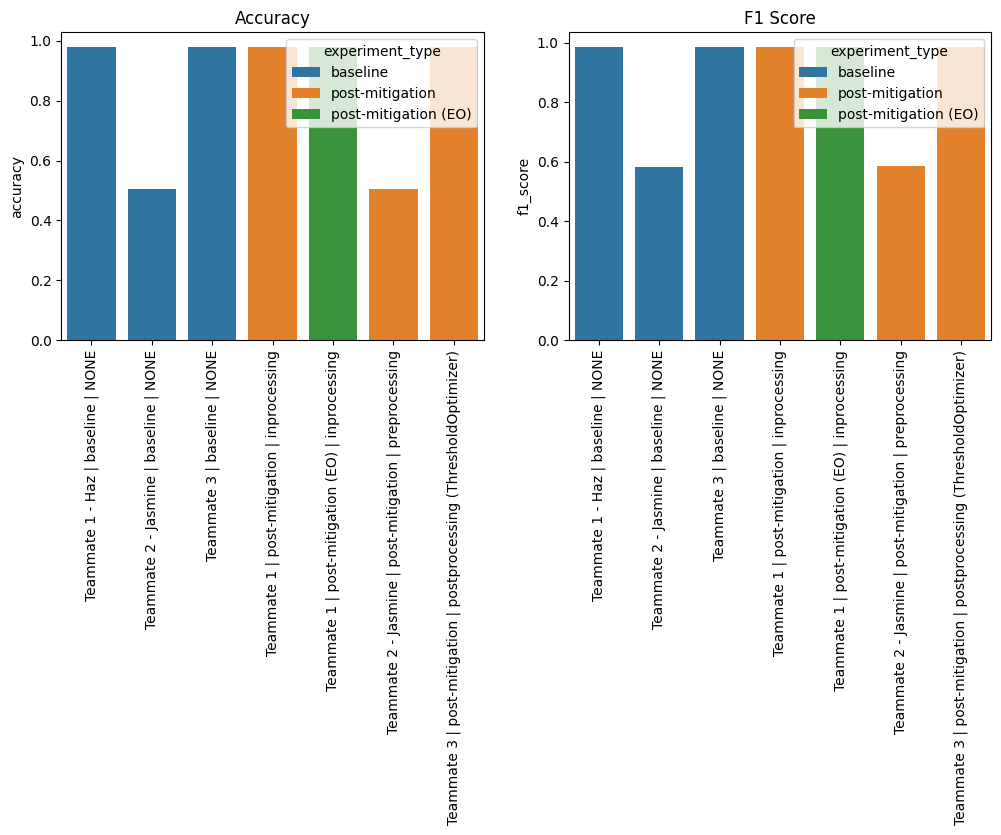

/var/folders/ln/z6rc7v8j2zq1wzsf4tdb0wpm0000gn/T/ipykernel_48566/3237065538.py:32: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


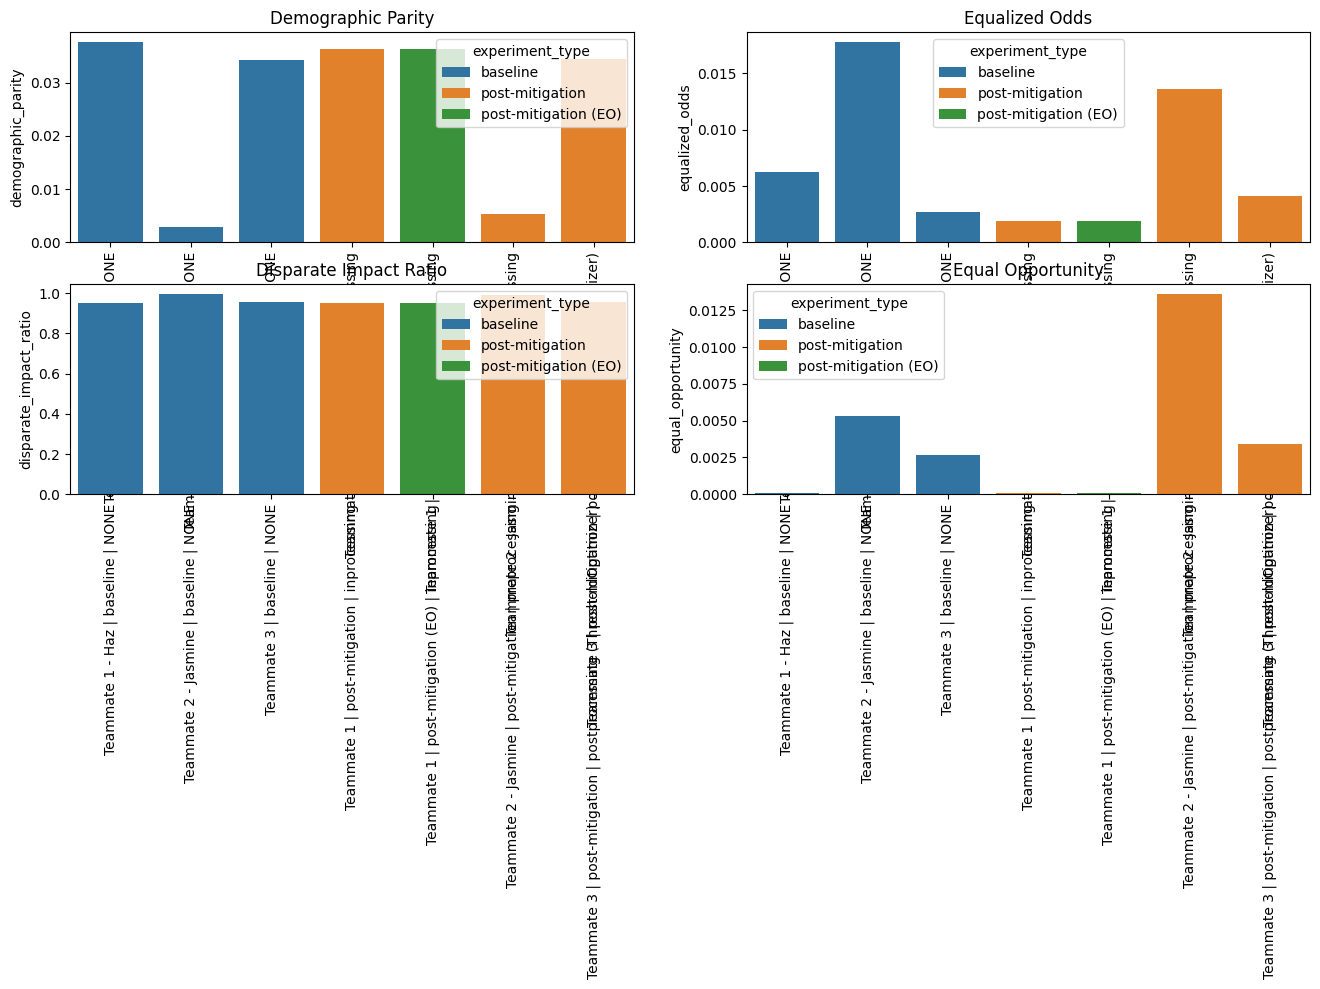

In [22]:
# Visualize performance and fairness metrics from overall_results

metrics_perf = ["accuracy", "f1_score"]
metrics_fair = ["demographic_parity", "equalized_odds", "disparate_impact_ratio", "equal_opportunity"]

results_plot = overall_results.copy()
results_plot["model_label"] = (
    results_plot["teammate"].astype(str)
    + " | "
    + results_plot["experiment_type"].astype(str)
    + " | "
    + results_plot["mitigation_strategy"].astype(str)
)

plt.figure(figsize=(12, 4))
for i, metric in enumerate(metrics_perf, 1):
    plt.subplot(1, 2, i)
    sns.barplot(data=results_plot, x="model_label", y=metric, hue="experiment_type")
    plt.title(metric.replace("_", " ").title())
    plt.xticks(rotation=90)
    plt.xlabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
for i, metric in enumerate(metrics_fair, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=results_plot, x="model_label", y=metric, hue="experiment_type")
    plt.title(metric.replace("_", " ").title())
    plt.xticks(rotation=90)
    plt.xlabel("")
plt.tight_layout()
plt.show()

# References

[List the references you used to complete this milestone here.]
- Teammate 1: Kamishima et al. ECML PKDD 2012, Fairness-Aware Classifier with Prejudice Remover Regularizer.
- Teammate 2: Kamiran and Calders. Knowledge and Information Systems 2012, Data Preprocessing Techniques for Classification without Discrimination.
- Teammate 3: Hardt et al. NeurIPS 2016, Equality of Opportunity in Supervised Learning.
- Teammate 4:

# Disclosures

[Disclose use of generative AI and similar tools here.]
- Teammate 1: No AI used to code.
- Teammate 2: No AI used to code.
- Teammate 3: No AI used to code.
- Teammate 4: